In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt 
import os
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
%matplotlib inline


In [2]:
FOLDER = 'jeanluke/anode_waveforms'
files = [f for f in os.listdir(FOLDER) if f.find("Cs") > 0]
files = np.sort(files)

signals = []
metadata = []

for i, file in enumerate(files):
    with h5py.File(f"{FOLDER}/{file}") as f:
        d = dict(f['metadata'].attrs)
        events = np.array(f['waveforms'])
        signals += [events]
        metadata += [d]

dose = [_["dose"] for _ in metadata]
signals = np.array(signals)[np.argsort(dose)]
metadata = np.array(metadata)[np.argsort(dose)]
files = np.array(files)[np.argsort(dose)]
dose = np.sort(dose)

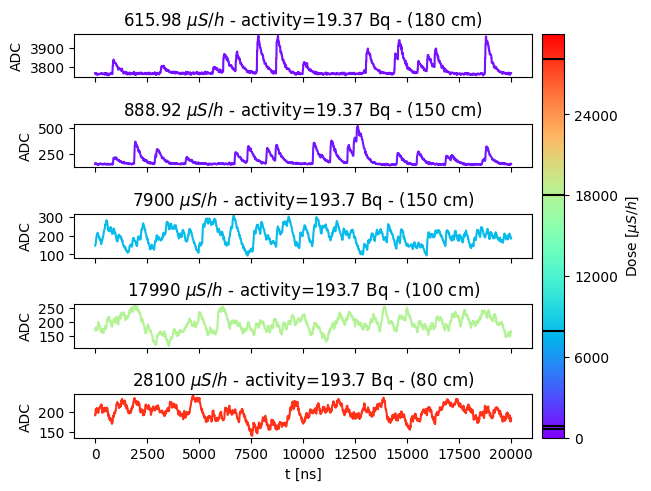

In [3]:
mosaic = np.array([np.arange(5), 5*["c"]]).T
fig,ax = plt.subplot_mosaic(mosaic,constrained_layout=True, sharex=False, width_ratios=[1, 0.05])
cm = plt.cm.rainbow
norm = Normalize(vmin=0, vmax = 30000)
for i in range(len(signals)):
    ax[str(i)].plot(np.arange(len(signals[i][0])).astype(float)*10, signals[i][100], color=cm(norm(metadata[i]['dose'])))
    ax[str(i)].set_title(fr"{metadata[i]['dose']} $\mu S/h$ - activity={metadata[i]['activity']} Bq - ({metadata[i]['distance']} cm)")
    ax[str(i)].set_ylabel("ADC")
    ax['c'].axhline(metadata[i]['dose'], color='k', zorder=100)
    if i < 4:
        ax[str(i)].set_xticklabels([])
    else:
        ax[str(i)].set_xlabel("t [ns]")

ax['c'].set_ylim(0, 30000)
plt.colorbar(ScalarMappable(cmap=cm, norm=norm), cax = ax['c'], label=r"Dose [$\mu S/ h $]")
ax['c'].set_yticks(np.arange(0,5)*30000/5)

fig.savefig("anode_signals.png", dpi=200)

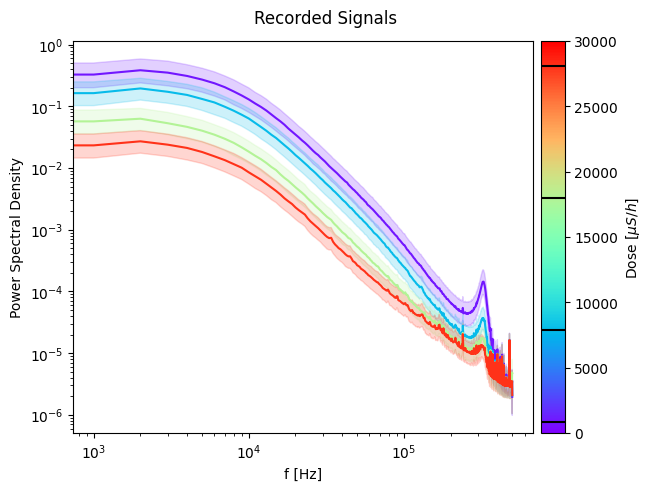

In [4]:
from scipy.signal import welch
fig, ax = plt.subplot_mosaic([["PSD","c"]], width_ratios=[1, 0.05], constrained_layout=True)
for i in range(1, 5):
    f, psd = welch(signals[i], axis=1, fs = 1e6, nperseg=1000, noverlap=500)
    ax["PSD"].plot(f, np.median(psd, axis=0), color=cm(norm(dose[i])))
    ax["PSD"].fill_between(f, *np.quantile(psd, [0.25, 0.75], axis=0), alpha = 0.2, color=cm(norm(dose[i])))
    ax['c'].axhline(metadata[i]['dose'], color='k', zorder=100)

ax["PSD"].set_xscale('log')
ax["PSD"].set_yscale('log')
plt.colorbar(ScalarMappable(cmap=cm, norm=norm), cax = ax['c'], label=r"Dose [$\mu S/ h $]")
ax["PSD"].set_ylabel("Power Spectral Density")
ax['PSD'].set_xlabel("f [Hz]")
fig.suptitle("Recorded Signals")

fig.savefig("PSD_true.png")

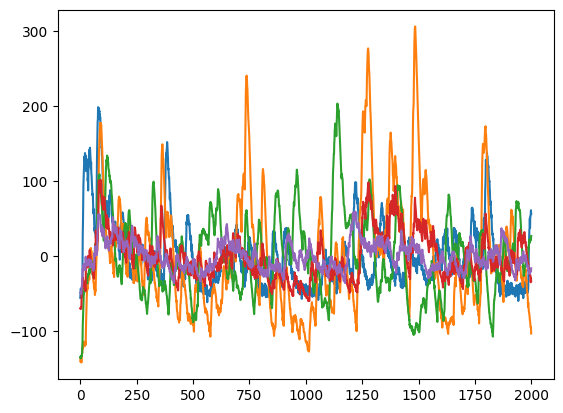

In [5]:
from sde_pulse_sim import simulate_sde
import json

with open("sde_fit_results.json", "r") as f:
    best_pars = json.load(f)

for file in files:
    pars = dict(lam=0, tau_rise=0, tau_fall=0, ser_mean=0.0, ser_cv=0.0,
                     noise_sigma=0)
    pars = {p:best_pars[file][p] for p in pars.keys()}
    y = simulate_sde(n_rec=1, n_samp=2000, **pars)

    plt.plot(y[0])

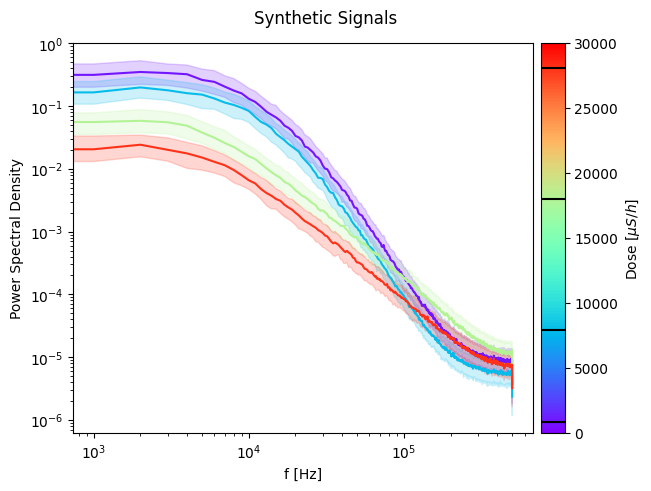

In [6]:
fig, ax = plt.subplot_mosaic([["PSD","c"]], width_ratios=[1, 0.05], constrained_layout=True)
for i in range(1, 5):
    pars = dict(lam=0, tau_rise=0, tau_fall=0, ser_mean=0.0, ser_cv=0.0,
                     noise_sigma=0)
    pars = {p:best_pars[files[i]][p] for p in pars.keys()}
    y = simulate_sde(n_rec=500, n_samp=2000, **pars)
    f, psd = welch(y, axis=1, fs = 1e6, nperseg=1000, noverlap=500)
    ax["PSD"].plot(f, np.median(psd, axis=0), color=cm(norm(dose[i])))
    ax["PSD"].fill_between(f, *np.quantile(psd, [0.25, 0.75], axis=0), alpha = 0.2, color=cm(norm(dose[i])))
    ax['c'].axhline(metadata[i]['dose'], color='k', zorder=100)

ax["PSD"].set_xscale('log')
ax["PSD"].set_yscale('log')
plt.colorbar(ScalarMappable(cmap=cm, norm=norm), cax = ax['c'], label=r"Dose [$\mu S/ h $]")
ax["PSD"].set_ylabel("Power Spectral Density")
ax['PSD'].set_xlabel("f [Hz]")
fig.suptitle("Synthetic Signals")
fig.savefig("PSD_synth.png")

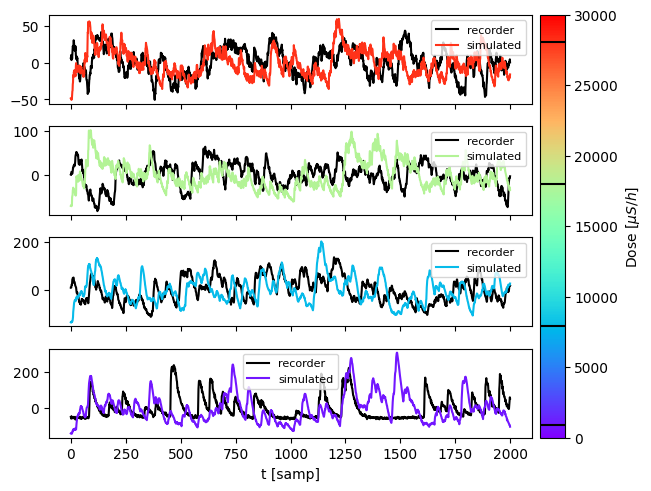

In [7]:
fig, ax = plt.subplot_mosaic([["1","c"], ["2", "c"], ["3","c"], ["4","c"]], width_ratios=[1, 0.05], constrained_layout=True)
for i in range(1, 5):
    pars = dict(lam=0, tau_rise=0, tau_fall=0, ser_mean=0.0, ser_cv=0.0,
                     noise_sigma=0)
    pars = {p:best_pars[files[i]][p] for p in pars.keys()}
    y = simulate_sde(n_rec=1, n_samp=2000, **pars)

    ax[str(5-i)].plot(signals[i][20] - np.mean(signals[i][20]), color="k", alpha=1, label="recorder")
    ax[str(5-i)].plot(y[0], color=cm(norm(dose[i])), alpha=1, label="simulated")

    if i < 4:
        ax[str(i)].set_xticklabels([])
    ax['c'].axhline(metadata[i]['dose'], color='k', zorder=100)
plt.colorbar(ScalarMappable(cmap=cm, norm=norm), cax = ax['c'], label=r"Dose [$\mu S/ h $]")
ax['4'].set_xlabel("t [samp]")
for i in range(1,5):
    ax[str(i)].legend(fontsize=8)

In [12]:
from signal_stats import signal_stats_err
stats = []
for i in range(1, 5):
    se = signal_stats_err(signals[i], n_boot=10)
    stats += [se]
    for k, (v, e) in se.items():
        print(f"{k:6s} = {v:12.4g} ± {e:.2g}")


mean   =        195.2 ± 0.083
std    =         67.1 ± 0.092
var    =         4503 ± 12
msd    =        46.86 ± 0.095
eta    =         96.1 ± 0.18
skew   =        1.829 ± 0.0056
kurt   =        4.013 ± 0.048
mean   =        195.2 ± 0.053
std    =         45.7 ± 0.027
var    =         2089 ± 2.5
msd    =           19 ± 0.0065
eta    =        109.9 ± 0.15
skew   =       0.1028 ± 0.0016
kurt   =      -0.2992 ± 0.0024
mean   =        194.6 ± 0.035
std    =        25.64 ± 0.016
var    =        657.5 ± 0.81
msd    =        8.646 ± 0.0027
eta    =        76.05 ± 0.097
skew   =      0.01548 ± 0.0021
kurt   =      -0.1069 ± 0.0043
mean   =          195 ± 0.02
std    =        17.26 ± 0.013
var    =        297.8 ± 0.45
msd    =        6.456 ± 0.002
eta    =        46.13 ± 0.068
skew   =      -0.1288 ± 0.0014
kurt   =      -0.0807 ± 0.0035


<ErrorbarContainer object of 3 artists>

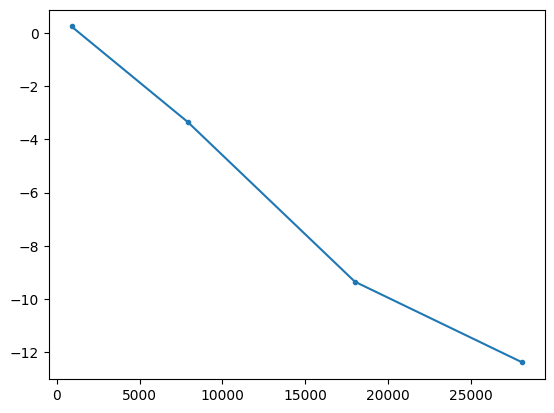

In [33]:
metric = [stats[i]['kurt'][0] for i in range(0, 4)]
err = [stats[i]['kurt'][1] for i in range(0, 4)]

plt.errorbar(dose[1:], 1/np.array(metric), marker=".", capsize=1)

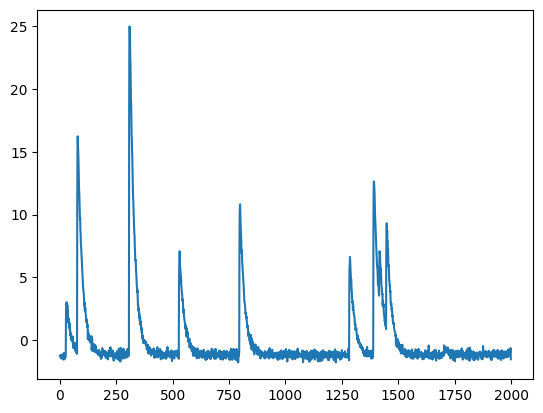

In [46]:
pars = dict(lam=0.5e6, 
           tau_rise=10e-9, 
           tau_fall=200e-9, 
           ser_mean=15, 
           ser_cv=0.7,
           noise_sigma=0.2)
y = simulate_sde(**pars)
plt.plot(y[0])

In [63]:
from signal_stats import signal_stats

N = 10
one_over_kurt = np.zeros((N, N))
eta = np.zeros((N, N))
lambdas = np.linspace(1e6, 5e7, N)
energies = np.linspace(5, 30, N)
for i, l in enumerate(lambdas):
    for j,en  in enumerate(energies):
        pars['lam'] = l
        pars['ser_mean'] = en
        y = simulate_sde(**pars)
        stats = signal_stats(y)
        one_over_kurt[i, j] = 1.0/stats['kurt']
        eta[i,j] = stats['eta']


<>:3: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:3: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
C:\Users\gbecuzzi\AppData\Local\Temp\ipykernel_39456\2056887808.py:3: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
  plt.colorbar(im, label="$\eta$")


Text(0.5, 0, '$\\lambda$ [Hz]')

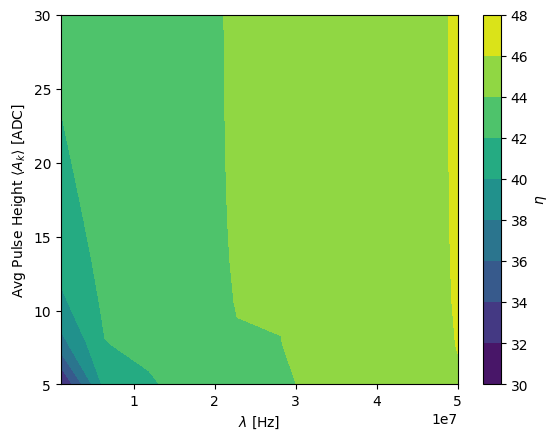

In [64]:
X, Y = np.meshgrid(lambdas, energies, indexing='ij')
im =plt.contourf(X, Y, eta)
plt.colorbar(im, label="$\eta$")
plt.ylabel(r"Avg Pulse Height $\langle A_k \rangle$ [ADC]")
plt.xlabel(r"$\lambda$ [Hz]")


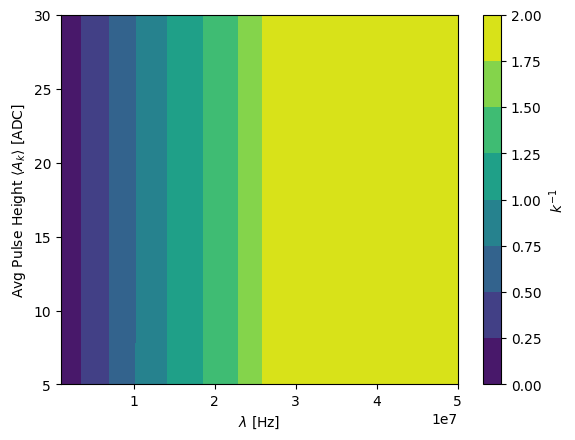

In [65]:
im = plt.contourf(X, Y, one_over_kurt)
plt.ylabel(r"Avg Pulse Height $\langle A_k \rangle$ [ADC]")
plt.xlabel(r"$\lambda$ [Hz]")
plt.colorbar(im, label = "$k^{-1}$")